## Trend Analysis: Use statistical methods to identify trends over time. 

Based on the guide provided, i tried to study the data, clean, provided the required models and algorithym to trend the data over the period and the parameters provided

## Data Understanding and Preprocessing 

## Steps i took.

I loaded the data, Displayed first 10 rows, Get the info about the Data, Get to know if there are dublicates of null values

In [1]:
import pandas as pd
df=pd.read_csv("WEATHER_REPORTS.CSV")

In [2]:
df.head(10)

,YEAR,MONTH,DAY,MERRA-2 Temperature at 2 Meters (C),MERRA-2 Temperature at 2 Meters Range (C),MERRA-2 Temperature at 2 Meters Maximum (C),MERRA-2 Temperature at 2 Meters Minimum (C),MERRA-2 Precipitation Corrected (mm/day),MERRA-2 Relative Humidity at 2 Meters (%),MERRA-2 Specific Humidity at 2 Meters (g/kg),MERRA-2 Wind Speed at 10 Meters (m/s),Latitude,Longitude
0,1990,1,1,27.65,17.71,37.23,19.51,0.0,19.00,4.03,2.42,9.406,13.462
1,1990,1,2,27.87,17.19,37.21,20.01,0.0,19.12,3.91,1.84,9.406,13.462
2,1990,1,3,27.79,17.03,37.00,19.96,0.0,15.50,3.23,2.38,9.406,13.462
3,1990,1,4,26.89,18.41,36.40,17.99,0.0,19.50,4.03,2.56,9.406,13.462
4,1990,1,5,27.76,18.21,37.14,18.94,0.0,20.50,4.39,2.50,9.406,13.462
5,1990,1,6,27.62,15.62,35.90,20.28,0.0,21.19,4.82,4.22,9.406,13.462
6,1990,1,7,27.54,15.73,35.90,20.16,0.0,18.81,4.27,5.57,9.406,13.462
7,1990,1,8,27.88,16.22,36.61,20.39,0.0,17.94,4.09,5.43,9.406,13.462
8,1990,1,9,28.14,16.01,37.20,21.19,0.0,19.44,4.76,5.79,9.406,13.462
9,1990,1,10,27.76,17.90,37.49,19.58,0.0,15.62,3.54,6.80,9.406,13.462


In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409761 entries, 0 to 409760
Data columns (total 13 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   YEAR                                           409761 non-null  int64  
 1   MONTH                                          409761 non-null  int64  
 2   DAY                                            409761 non-null  int64  
 3   MERRA-2 Temperature at 2 Meters (C)            409761 non-null  float64
 4   MERRA-2 Temperature at 2 Meters Range (C)      409761 non-null  float64
 5   MERRA-2 Temperature at 2 Meters Maximum (C)    409761 non-null  float64
 6    MERRA-2 Temperature at 2 Meters Minimum (C)   409761 non-null  float64
 7   MERRA-2 Precipitation Corrected (mm/day)       409761 non-null  float64
 8   MERRA-2 Relative Humidity at 2 Meters (%)      409761 non-null  float64
 9   MERRA-2 Specific Humidity at 2 Meters

## Data Cleaning  

I renamed the columns for easy refrencing, Created a date time column and Removed Dudlicate rows, missing values if any and checked the cleaning


In [18]:
# Column renaming for easy refrence
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

#YEAR, MONTH, DAY 
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Date covnersion
    df.set_index('date', inplace=True)

# Removed dublicate rows
    df.drop_duplicates(inplace=True)

# Handle missing values if any
    df.dropna(inplace=True)

print("✅ Cleaned DataFrame:")
print(df.head())

✅ Cleaned DataFrame:
            year  month  day  merra2_temperature_at_2_meters_c  \
date                                                             
1990-01-01  1990      1    1                             27.65   
1990-01-02  1990      1    2                             27.87   
1990-01-03  1990      1    3                             27.79   
1990-01-04  1990      1    4                             26.89   
1990-01-05  1990      1    5                             27.76   

            merra2_temperature_at_2_meters_range_c  \
date                                                 
1990-01-01                                   17.71   
1990-01-02                                   17.19   
1990-01-03                                   17.03   
1990-01-04                                   18.41   
1990-01-05                                   18.21   

            merra2_temperature_at_2_meters_maximum_c  \
date                                                   
1990-01-01               

## Feature Engineering

Imported the required libraries and created a numeric time variable

In [26]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
df['time'] = df['date'].dt.year + (df['date'].dt.dayofyear / 365)

## Model Development - Trend Analysis Function
Based on the guide function definition
linear regression model applicaiton using slope to check the change, r_vlaue to check for change and p_value to check the significance of the change
I also defined the variable for plotting the graph in this stage

In [22]:
def analyze_trend(df, col, label):
    x = df['time']               # Independent variable (time)
    y = df[col]                  # Dependent variable (climate metric)

# My linear regression model
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Results expected
    print(f"\n📊 {label} Trend Analysis")
    print(f"Annual Change: {slope:.4f}")
    print(f"R² (Trend Strength): {r_value**2:.3f}")
    print(f"P-value: {p_value:.4f} -> {'Significant ✅' if p_value < 0.05 else 'Not Significant ❌'}")

# Variables for ploting
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, alpha=0.3, label='Observed Data')
    plt.plot(x, intercept + slope * x, color='red', label='Trend Line')
    plt.title(f"{label} Over Time")
    plt.xlabel("Year")
    plt.ylabel(label)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Choosing Algorithms and Selecting Features
Based on my study of the data, I used linear regression (line of best fit) because it's interpretable and well-suited for identifying long-term trends.
Temperature, Precipitation, Humidity and Wind Speed

In [23]:
# Columns to analyse
climate_features = {
    'merra2_temperature_at_2_meters_c': 'Temperature (°C)',
    'merra2_precipitation_corrected_mmday': 'Precipitation (mm/day)',
    'merra2_relative_humidity_at_2_meters_': 'Relative Humidity (%)',
    'merra2_wind_speed_at_10_meters_ms': 'Wind Speed (m/s)'
}

 ## Model Interpretation and Deployment
As seen above this codes is to run each climate from teh climate feature variable above


📊 Temperature (°C) Trend Analysis
Annual Change: 0.0261
R² (Trend Strength): 0.008
P-value: 0.0000 -> Significant ✅


C:\Users\469775\AppData\Local\Temp\ipykernel_37940\341118973.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\469775\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


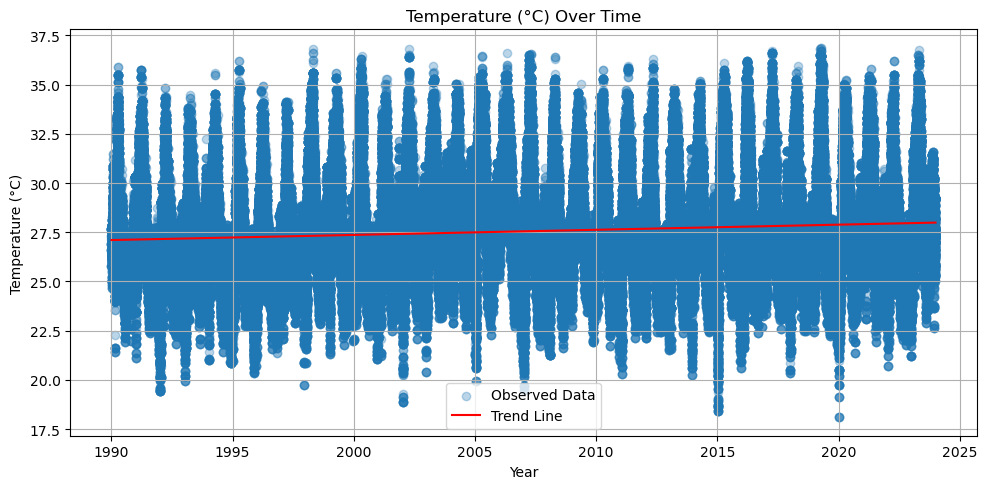


📊 Precipitation (mm/day) Trend Analysis
Annual Change: -0.0014
R² (Trend Strength): 0.000
P-value: 0.1019 -> Not Significant ❌


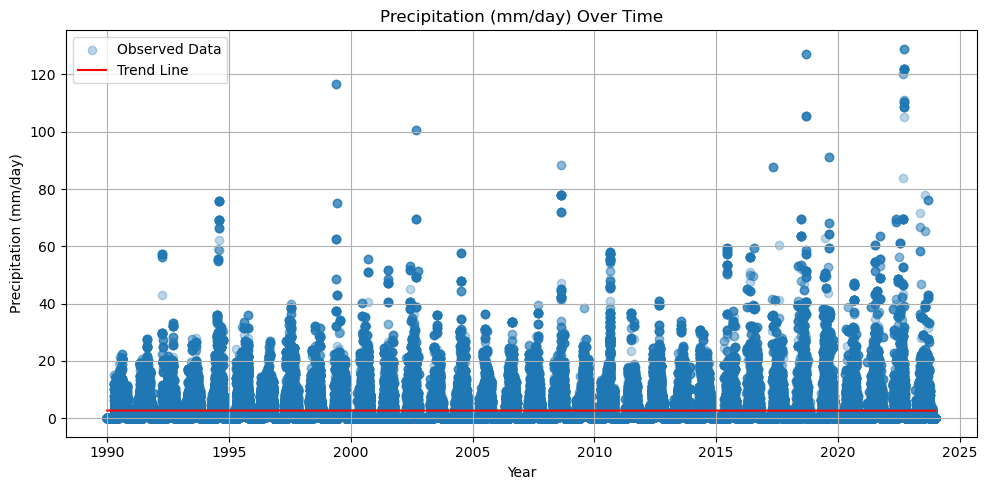


📊 Relative Humidity (%) Trend Analysis
Annual Change: -0.0319
R² (Trend Strength): 0.000
P-value: 0.0000 -> Significant ✅


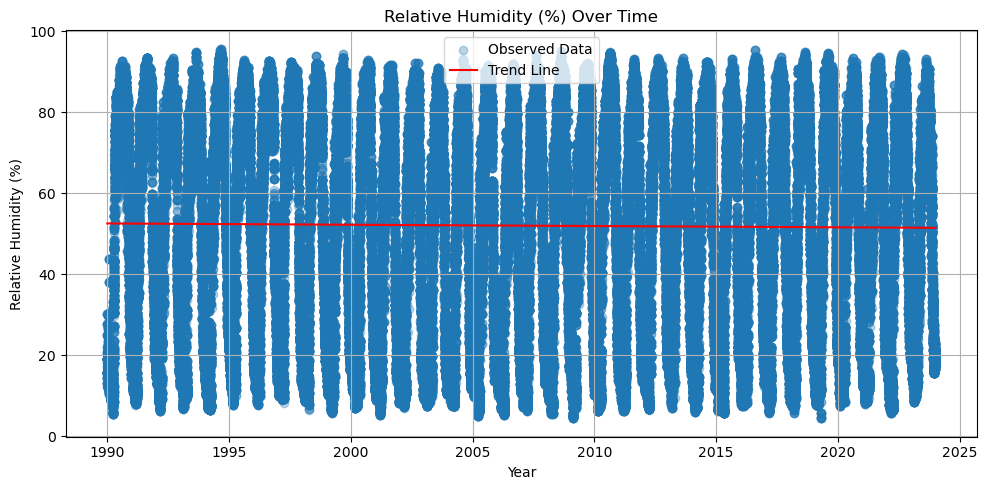


📊 Wind Speed (m/s) Trend Analysis
Annual Change: -0.0045
R² (Trend Strength): 0.001
P-value: 0.0000 -> Significant ✅


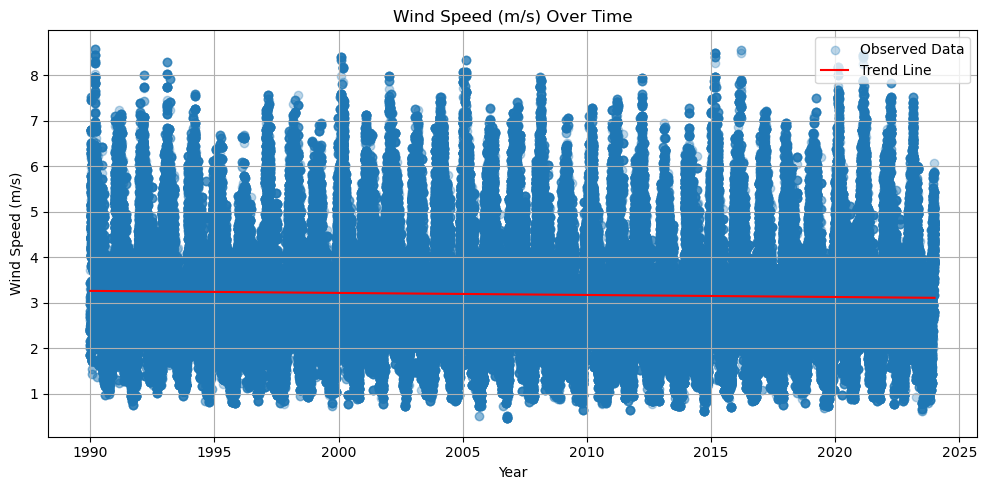

In [24]:
# This codes is to run each climate from teh climate feature variable above
for col, label in climate_features.items():
    analyze_trend(df, col, label)


## Ethical Considerations

In [ ]:
# =====================================================
# 🧭 Ethical Considerations
# =====================================================

# ✅ Ethical Notes:
# - We're using publicly available climate data, ensuring transparency and reproducibility.
# - The trends we find are statistical, not causal. They must be interpreted with domain knowledge.
# - Climate data can be sensitive for local planning. Ensure accurate communication when sharing.
# - Visualization and results should be contextualized with geographical or socio-economic data
#   before driving any decision-making processes.
